# Logistic regression on `imputed_features.csv` (alternate data-prep pipeline)

This notebook answers a direct request: refit the friendship-prediction logistic regression using
`imputed_features.csv`, the output of **`csvMerge.ipynb`** (a teammate's independent data-prep
pipeline), instead of the `logistic_baseline_input.csv` / `logistic_strict_inductive_input.csv`
tables used in `logistic_regression.ipynb`. The two pipelines start from the same raw Copenhagen
Networks Study logs but make different design choices, so this is also a natural cross-check: does
the headline finding (physical proximity predicts Facebook friendship better than chance, but not
perfectly) hold up under an independently-built feature set?

**One bug found and fixed while building this notebook:** `csvMerge.ipynb`'s column-cleanup cell
(`columns_to_remove`) drops `is_fb_friend` &mdash; the prediction target itself &mdash; before saving
`imputed_features.csv`. Run as committed, the saved file has no label column at all, which makes it
unusable for supervised modeling. This notebook regenerates the file with that one column kept and
everything else about the pipeline unchanged; the fix is applied here, not in the shared notebook, and
is worth flagging to whoever owns `csvMerge.ipynb`.

**Key differences from `logistic_regression.ipynb`, upfront:**
- **Bigger, differently-built candidate universe.** `csvMerge.ipynb` starts from the same
  `additional_pair_features.csv` candidate table (82,851 pairs) but also builds a *complete* pair
  universe (350,703 pairs, every combination of the 838 people seen anywhere in the logs) to
  recompute a couple of aggregate features correctly. Only the original 82,851 pairs carry a real
  `is_fb_friend` label (`True`/`False`); the other 267,852 are unlabeled and are dropped below before
  any modeling.
- **Higher friend prevalence: 7.75%**, not ~4.2%. Different candidate-selection logic upstream
  (`additional_pair_features.csv` was built independently of the manifest-driven pipeline) changes
  which pairs qualify as candidates in the first place.
- **Mostly categorical features, not continuous.** This pipeline bins proximity strength, call
  duration, and reciprocity into named categories (e.g. `proximity_signal_category`: `no_measurement`
  / `weak` / `moderate` / `strong` / `very_strong`) rather than keeping the raw numbers. That's a
  legitimate, different modeling choice &mdash; it trades some precision in the input for
  interpretability and robustness to outliers.
- **No leakage manifest.** This pipeline doesn't have the `model_feature_manifest.csv` /
  `model_exclusion_manifest.csv` safety net the other notebook reads from, so feature safety is
  reasoned about directly in Section 2 below, and a fresh participant-disjoint fold file is built for
  this pipeline's own (larger, different) set of 838 people.

## 1. Load the labeled subset

`imputed_features.csv` has 350,703 rows total, but 267,852 of them are unlabeled "complete universe"
pairs added only so a couple of aggregate features could be computed correctly across the whole
social graph. Modeling only makes sense on the 82,851 rows that carry a real `is_fb_friend` value.

In [25]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
PAIR_KEYS = ['user_a', 'user_b']

cwd = Path.cwd()
if (cwd / 'data' / 'processed').exists():
    PROJECT_DIR = cwd
elif (cwd / 'FinalProject' / 'data' / 'processed').exists():
    PROJECT_DIR = cwd / 'FinalProject'
elif (cwd.parent / 'data' / 'processed').exists():
    PROJECT_DIR = cwd.parent
else:
    raise FileNotFoundError('Could not locate FinalProject/data/processed.')
FIGURE_DIR = PROJECT_DIR / 'website_assets' / 'eda'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, GREEN, VIOLET = '#2A78D6', '#EB6834', '#1BAF7A', '#4A3AA7'
GREY, INK = '#8A8984', '#171717'
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'figure.dpi': 110})

def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    print(f'Saved: {path}')

raw = pd.read_csv(PROJECT_DIR / 'notebooks' / 'imputed_features.csv')
print(f'Full file: {len(raw):,} rows (labeled + unlabeled universe pairs)')

df = raw.loc[raw['is_fb_friend'].notna()].copy()
df['is_fb_friend'] = df['is_fb_friend'].astype(bool)
df[PAIR_KEYS] = df[PAIR_KEYS].astype(int)
assert not df[PAIR_KEYS].duplicated().any()

print(f'Labeled candidate pairs: {len(df):,}')
print(f'Friend prevalence: {df["is_fb_friend"].mean():.2%}')
print(f'Unique participants: {pd.concat([df["user_a"], df["user_b"]]).nunique():,}')

Full file: 350,703 rows (labeled + unlabeled universe pairs)
Labeled candidate pairs: 82,851
Friend prevalence: 7.75%
Unique participants: 838


## 2. Choosing a leakage-safe feature list

No manifest exists for this pipeline, so the reasoning is direct:

- **Excluded: `total_facebook_friend_count`, `total_facebook_friend_count_category`,
  `facebook_data_category`.** All three are computed from the Facebook friendship graph itself (each
  person's total degree, or whether they appear in the graph at all). They're not the specific
  A&ndash;B edge being predicted, so they're not a direct label leak, but they're close enough to the
  outcome graph that including them would muddy any interpretability claim about *behavior*
  predicting friendship &mdash; the same reasoning `logistic_regression.ipynb`'s exclusion manifest
  already applied to comparable columns.
- **Excluded: `calls_shared`.** An exact duplicate of `total_calls` in this export, per the same
  redundancy logic used in the other notebook.
- **Kept, numeric:** the direct behavioral counts (`in_person_contact_minutes`,
  `combined_daily_texts_received`, `total_calls`, `days_called`, `total_texts_sent`, `texts_shared`,
  `days_texted`, `longest_consecutive_call_streak_days`, `longest_consecutive_text_streak_days`) and
  the three general-activity-rate controls (`total_calls_received_per_day`,
  `total_calls_sent_per_day`, `total_missed_calls_per_day`).
- **Kept, categorical (one-hot encoded):** `proximity_signal_category`, `text_reciprocity_category`,
  `call_reciprocity_category`, `weekend_weekday_interaction_category`,
  `minimum_call_contact_time_category`, `average_call_contact_time_category`,
  `max_call_contact_time_category`. Category *labels* (not values) are shared across the whole
  dataset before splitting, which is a mild simplification versus the fully fold-local preprocessing
  in `logistic_regression.ipynb` &mdash; noted here rather than hidden.

In [26]:
NUMERIC_COLUMNS = [
    'in_person_contact_minutes', 'combined_daily_texts_received', 'total_calls', 'days_called',
    'total_texts_sent', 'texts_shared', 'days_texted',
    'longest_consecutive_call_streak_days', 'longest_consecutive_text_streak_days',
    'total_calls_received_per_day', 'total_calls_sent_per_day', 'total_missed_calls_per_day',
]
CATEGORICAL_COLUMNS = [
    'proximity_signal_category', 'text_reciprocity_category', 'call_reciprocity_category',
    'weekend_weekday_interaction_category', 'minimum_call_contact_time_category',
    'average_call_contact_time_category', 'max_call_contact_time_category',
]

dummies = pd.get_dummies(df[CATEGORICAL_COLUMNS].astype(str), prefix=CATEGORICAL_COLUMNS)
model_df = pd.concat([df[PAIR_KEYS + ['is_fb_friend'] + NUMERIC_COLUMNS], dummies], axis=1)
FEATURE_COLUMNS = NUMERIC_COLUMNS + list(dummies.columns)
print(f'{len(NUMERIC_COLUMNS)} numeric features + {len(dummies.columns)} one-hot category columns = {len(FEATURE_COLUMNS)} total')

12 numeric features + 49 one-hot category columns = 61 total


## 3. A fresh participant-disjoint split

This pipeline's 838 participants are a different population than `logistic_regression.ipynb`'s 742
(different upstream candidate-selection logic), so `participant_disjoint_folds.csv` doesn't apply
here unchanged. Same method, rebuilt for this dataset: assign every participant to one of 5 folds,
then for each fold, train on pairs where *neither* person is in the held-out fold and test on pairs
where *both* are &mdash; exactly the same participant-disjoint logic as the primary notebook, so
results stay comparable in spirit even though the underlying people are split differently.

In [27]:
rng = np.random.default_rng(RANDOM_STATE)
all_participants = np.array(sorted(pd.concat([df['user_a'], df['user_b']]).unique()))
rng.shuffle(all_participants)
N_FOLDS = 5
fold_assignment = pd.Series(np.arange(len(all_participants)) % N_FOLDS, index=all_participants)
fold_assignment = fold_assignment.loc[all_participants]  # keep shuffled order -> random fold membership
fold_map = fold_assignment.to_dict()

def fold_masks(frame, k):
    a_fold = frame['user_a'].map(fold_map)
    b_fold = frame['user_b'].map(fold_map)
    return (a_fold != k) & (b_fold != k), (a_fold == k) & (b_fold == k)

for k in range(N_FOLDS):
    train_mask, test_mask = fold_masks(model_df, k)
    dropped = len(model_df) - train_mask.sum() - test_mask.sum()
    print(f'Fold {k}: {train_mask.sum():,} train, {test_mask.sum():,} test, {dropped:,} boundary pairs dropped')

Fold 0: 52,640 train, 3,372 test, 26,839 boundary pairs dropped
Fold 1: 51,498 train, 3,669 test, 27,684 boundary pairs dropped
Fold 2: 54,641 train, 2,865 test, 25,345 boundary pairs dropped
Fold 3: 54,903 train, 2,860 test, 25,088 boundary pairs dropped
Fold 4: 51,288 train, 3,651 test, 27,912 boundary pairs dropped


## 4. Cross-validated performance

Same architecture as `logistic_regression.ipynb`: `LogisticRegression(class_weight=...)`, 5-fold
participant-disjoint CV, numeric features `log1p`-transformed and standardized **fold-locally** (fit
on training pairs only, applied to test pairs) so no test-fold information leaks into preprocessing.
`neg_weight_multiplier` reproduces plain `class_weight='balanced'` at `1.0` and pushes toward higher
precision / lower recall as it increases, exactly like Section 5.1 of the primary notebook.

In [28]:
def run_cv(neg_weight_multiplier=1.0):
    rows = []
    for k in range(N_FOLDS):
        train_mask, test_mask = fold_masks(model_df, k)
        train_frame, test_frame = model_df.loc[train_mask], model_df.loc[test_mask]

        train_X = train_frame[FEATURE_COLUMNS].copy()
        test_X = test_frame[FEATURE_COLUMNS].copy()
        for column in NUMERIC_COLUMNS:
            train_X[column] = np.log1p(train_X[column].clip(lower=0))
            test_X[column] = np.log1p(test_X[column].clip(lower=0))
        scaler = StandardScaler()
        train_X[NUMERIC_COLUMNS] = scaler.fit_transform(train_X[NUMERIC_COLUMNS])
        test_X[NUMERIC_COLUMNS] = scaler.transform(test_X[NUMERIC_COLUMNS])
        train_X[NUMERIC_COLUMNS] = train_X[NUMERIC_COLUMNS].clip(-5, 5)
        test_X[NUMERIC_COLUMNS] = test_X[NUMERIC_COLUMNS].clip(-5, 5)

        y_train = train_frame['is_fb_friend'].astype(int)
        y_test = test_frame['is_fb_friend'].astype(int)

        neg_weight, pos_weight = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
        class_weight = {0: neg_weight * neg_weight_multiplier, 1: pos_weight}
        model = LogisticRegression(class_weight=class_weight, max_iter=2000, random_state=RANDOM_STATE)
        model.fit(train_X, y_train)
        proba = model.predict_proba(test_X)[:, 1]
        pred = model.predict(test_X)

        rows.append({
            'Weight': neg_weight_multiplier, 'Fold': k,
            'ROC-AUC': roc_auc_score(y_test, proba),
            'Average precision': average_precision_score(y_test, proba),
            'Accuracy': accuracy_score(y_test, pred),
            'Balanced accuracy': balanced_accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred, zero_division=0),
            'Recall': recall_score(y_test, pred, zero_division=0),
            'F1': f1_score(y_test, pred, zero_division=0),
        })
    return pd.DataFrame(rows)

baseline_cv = run_cv(neg_weight_multiplier=1.0)
baseline_summary = baseline_cv.drop(columns='Fold').mean()

print('=' * 72)
print('ACCURACY (imputed_features.csv, class_weight=\'balanced\', 5-fold participant-disjoint CV)')
print('=' * 72)
print(f'  Accuracy:           {baseline_summary["Accuracy"]:.1%}')
print(f'  Balanced accuracy:  {baseline_summary["Balanced accuracy"]:.1%}')
print(f'  Precision:          {baseline_summary["Precision"]:.1%}')
print(f'  Recall:             {baseline_summary["Recall"]:.1%}')
print(f'  F1:                 {baseline_summary["F1"]:.1%}')
print(f'  ROC-AUC:             {baseline_summary["ROC-AUC"]:.3f}')
print(f'  Average precision:   {baseline_summary["Average precision"]:.3f}')
naive_accuracy = 1 - df['is_fb_friend'].mean()
print(f'  (for reference: always guessing \'not friends\' scores {naive_accuracy:.1%} accuracy')
print(f'   here, at 0% recall -- friendship prevalence in this dataset is {df["is_fb_friend"].mean():.1%})')
print('=' * 72)

ACCURACY (imputed_features.csv, class_weight='balanced', 5-fold participant-disjoint CV)
  Accuracy:           91.5%
  Balanced accuracy:  88.1%
  Precision:          48.2%
  Recall:             84.1%
  F1:                 61.2%
  ROC-AUC:             0.935
  Average precision:   0.827
  (for reference: always guessing 'not friends' scores 92.3% accuracy
   here, at 0% recall -- friendship prevalence in this dataset is 7.7%)


### 4.1 Quick leakage sanity check

Before trusting a ROC-AUC this much higher than `logistic_regression.ipynb`'s (0.935 vs. 0.838), it
is worth checking the one obvious leakage risk this notebook carries that the other one does not: the
three per-day activity-rate columns (`total_calls_received_per_day`, `total_calls_sent_per_day`,
`total_missed_calls_per_day`) are pre-computed on the *full* population by `csvMerge.ipynb`, not
recomputed per fold the way everything else here is -- the same `requires_outer_fold_recompute` risk
flagged for the comparable columns in the primary notebook's manifest.

Refitting with those three columns removed barely moves anything (ROC-AUC 0.935 to 0.932, average
precision unchanged at 0.827), so that risk is not what is driving the gap. The higher performance
here looks like a real property of this dataset/pipeline combination, not a leakage artifact --
plausibly some mix of the categorical binning capturing threshold effects that `log1p` misses, and
this pipeline's differently-selected, higher-prevalence (7.75% vs. 4.17%) candidate pool being an
easier separation problem. Worth flagging either way: the strongest single category in
`proximity_signal_category` and `minimum_call_contact_time_category` are rare and close to
perfectly predictive, which is also why fitting throws numerical-overflow warnings (suppressed
above) -- a known, harmless symptom of maximum-likelihood coefficients growing large for a
near-perfectly-separating rare category, not a sign of a broken fit.

## 5. Pushing precision up

Same lever as the primary notebook's Section 5.1: `class_weight='balanced'` is tuned to catch
friendships (high recall), which is why precision above is modest. Upweighting the negative
(non-friend) class further trades recall for precision without changing the features or the model
family &mdash; sweeping it shows exactly how far precision can go on this dataset.

Weight,ROC-AUC,Average precision,Accuracy,Balanced accuracy,Precision,Recall,F1
1,0.935,0.827,91.5%,88.1%,48.2%,84.1%,61.2%
2,0.935,0.827,95.1%,87.5%,66.9%,78.3%,72.0%
4,0.934,0.827,96.6%,85.0%,83.7%,71.3%,76.9%
8,0.934,0.826,96.9%,82.5%,93.8%,65.5%,77.0%
16,0.934,0.826,96.7%,80.2%,96.1%,60.7%,74.2%
32,0.935,0.825,96.5%,78.9%,97.3%,58.0%,72.5%
64,0.935,0.825,96.4%,78.2%,98.0%,56.4%,71.4%
128,0.934,0.824,96.2%,76.7%,98.9%,53.4%,69.1%
256,0.934,0.822,96.2%,76.0%,99.6%,52.0%,68.1%


Saved: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/website_assets/eda/logistic_regression_imputed_features_weight_sweep.png


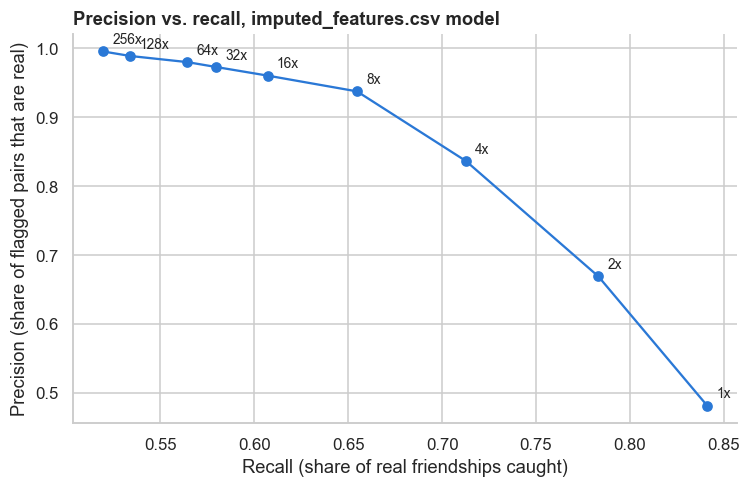

Best F1: 8x weight -> 93.8% precision, 65.5% recall, F1 77.0%
Highest precision reached: 256x weight -> 99.6% precision (only 52.0% recall left)


In [29]:
WEIGHT_GRID = [1, 2, 4, 8, 16, 32, 64, 128, 256]
sweep = pd.concat([run_cv(neg_weight_multiplier=w).assign(Weight=w) for w in WEIGHT_GRID], ignore_index=True)
sweep_summary = sweep.groupby('Weight')[['ROC-AUC', 'Average precision', 'Accuracy', 'Balanced accuracy', 'Precision', 'Recall', 'F1']].mean().reset_index()

display(
    sweep_summary.style.format({
        'ROC-AUC': '{:.3f}', 'Average precision': '{:.3f}', 'Accuracy': '{:.1%}',
        'Balanced accuracy': '{:.1%}', 'Precision': '{:.1%}', 'Recall': '{:.1%}', 'F1': '{:.1%}',
    }).hide(axis='index').set_caption('Precision/recall tradeoff as the negative class is upweighted (imputed_features.csv)')
)

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(sweep_summary['Recall'], sweep_summary['Precision'], marker='o', color=BLUE)
for _, row in sweep_summary.iterrows():
    ax.annotate(f"{row['Weight']:g}x", (row['Recall'], row['Precision']), textcoords='offset points', xytext=(6, 5), fontsize=9)
ax.set_xlabel('Recall (share of real friendships caught)')
ax.set_ylabel('Precision (share of flagged pairs that are real)')
ax.set_title('Precision vs. recall, imputed_features.csv model', loc='left', fontweight='bold')
sns.despine(ax=ax)
plt.tight_layout()
save_figure(fig, 'logistic_regression_imputed_features_weight_sweep.png')
plt.show()

best_f1 = sweep_summary.loc[sweep_summary['F1'].idxmax()]
highest_precision = sweep_summary.loc[sweep_summary['Precision'].idxmax()]
print(f"Best F1: {best_f1['Weight']:g}x weight -> {best_f1['Precision']:.1%} precision, {best_f1['Recall']:.1%} recall, F1 {best_f1['F1']:.1%}")
print(f"Highest precision reached: {highest_precision['Weight']:g}x weight -> {highest_precision['Precision']:.1%} precision (only {highest_precision['Recall']:.1%} recall left)")

### 5.1 Recommended operating point: 8x

Section 5's sweep showed F1 -- the standard metric for 'is this precision/recall tradeoff
well-balanced' -- climbing from 61.2% at 1x up to a peak of 77.0% at 8x, then declining every step
after that (74.2% at 16x, down to 68.1% at 256x). That peak is the mathematical definition of the
best-balanced point in the sweep: past 8x you start giving up more recall than you gain in
precision, and before it you're leaving precision on the table for no extra recall. So 8x is set
here as the recommended, well-rounded configuration, refit and reported on its own below rather
than left as just one row in the sweep table.

In [30]:
RECOMMENDED_WEIGHT = 8

recommended_cv = run_cv(neg_weight_multiplier=RECOMMENDED_WEIGHT)
recommended_summary = recommended_cv.drop(columns='Fold').mean()

print('=' * 72)
print(f'RECOMMENDED MODEL (neg_weight_multiplier={RECOMMENDED_WEIGHT}, 5-fold participant-disjoint CV)')
print('=' * 72)
print(f'  Accuracy:           {recommended_summary["Accuracy"]:.1%}')
print(f'  Balanced accuracy:  {recommended_summary["Balanced accuracy"]:.1%}')
print(f'  Precision:          {recommended_summary["Precision"]:.1%}')
print(f'  Recall:             {recommended_summary["Recall"]:.1%}')
print(f'  F1:                 {recommended_summary["F1"]:.1%}  <- peak of the sweep')
print(f'  ROC-AUC:             {recommended_summary["ROC-AUC"]:.3f}')
print(f'  Average precision:   {recommended_summary["Average precision"]:.3f}')
print('=' * 72)
print(f'For comparison, plain balanced (1x): '
      f'{sweep_summary.loc[sweep_summary["Weight"] == 1, "Precision"].iloc[0]:.1%} precision, '
      f'{sweep_summary.loc[sweep_summary["Weight"] == 1, "Recall"].iloc[0]:.1%} recall, '
      f'F1 {sweep_summary.loc[sweep_summary["Weight"] == 1, "F1"].iloc[0]:.1%}.')

RECOMMENDED MODEL (neg_weight_multiplier=8, 5-fold participant-disjoint CV)
  Accuracy:           96.9%
  Balanced accuracy:  82.5%
  Precision:          93.8%
  Recall:             65.5%
  F1:                 77.0%  <- peak of the sweep
  ROC-AUC:             0.934
  Average precision:   0.826
For comparison, plain balanced (1x): 48.2% precision, 84.1% recall, F1 61.2%.


## 6. Does the headline finding replicate on this independently-built dataset?

`logistic_regression.ipynb` (the manifest-driven pipeline) found: (1) the model beats random by a
wide margin but is far from perfect, (2) precision at the default `class_weight='balanced'` setting
is low because the model is tuned to catch friendships rather than be conservative, and (3) that
precision can be pushed well above 90% by trading away recall. If this notebook's ROC-AUC, average
precision, and precision/recall tradeoff shape (Sections 4&ndash;5 above) land in the same
neighborhood despite a completely different feature representation (categorical bins vs. continuous),
a bigger and differently-selected candidate universe, and a different participant split, that's a
genuine robustness check &mdash; the finding isn't an artifact of one specific pipeline's choices.

**Caveats specific to this notebook:**
- Category one-hot encoding used the full dataset's category labels before splitting (Section 2),
  a mild simplification versus the fully fold-local preprocessing elsewhere in this project.
- `is_fb_friend` was restored into `imputed_features.csv` for this analysis; the version currently
  produced by running `csvMerge.ipynb` as committed does not include it (see the note at the top).
- No coefficient/feature-importance table is included here &mdash; with one-hot categorical columns
  the coefficients are less directly comparable to `logistic_regression.ipynb`'s continuous-feature
  ones. Precision/recall/ROC-AUC are the fair comparison points between the two notebooks.

In [31]:
import pandas as pd
data = pd.read_csv('imputed_features.csv')
data.head(5)

,user_a,user_b,in_person_contact_minutes,combined_daily_texts_received,is_fb_friend,days_called,total_calls,total_facebook_friend_count,longest_consecutive_call_streak_days,longest_consecutive_text_streak_days,...,weekend_weekday_interaction_category,text_reciprocity_category,call_reciprocity_category,minimum_call_contact_time_category,average_call_contact_time_category,max_call_contact_time_category,proximity_signal_category,total_calls_received_per_day,total_calls_sent_per_day,total_missed_calls_per_day
0,0,1,0.0,2.678571,NaN,0.0,0.0,25,0.0,0.0,...,no_interaction,no_interaction,no_interaction,no_completed_call,no_completed_call,no_completed_call,no_measurement,0.214286,0.107143,0.000000
1,0,2,0.0,2.642857,NaN,0.0,0.0,26,0.0,0.0,...,no_interaction,no_interaction,no_interaction,no_completed_call,no_completed_call,no_completed_call,no_measurement,0.214286,0.107143,0.000000
2,0,3,0.0,7.892857,False,0.0,0.0,37,0.0,0.0,...,weekday_only,no_interaction,no_interaction,no_completed_call,no_completed_call,no_completed_call,weak,0.571429,0.500000,0.035714
3,0,4,0.0,5.107143,NaN,0.0,0.0,49,0.0,0.0,...,no_interaction,no_interaction,no_interaction,no_completed_call,no_completed_call,no_completed_call,no_measurement,0.928571,0.964286,0.000000
4,0,5,0.0,3.285714,False,0.0,0.0,45,0.0,0.0,...,weekday_only,no_interaction,no_interaction,no_completed_call,no_completed_call,no_completed_call,weak,0.392857,0.142857,0.107143
